[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevisback/bda-course/blob/main/wise2627/notebooks/01_geschichte_und_use_cases.ipynb)

*Präsentations-Notebook für Sitzung 1 — als Diashow starten (Ansicht → Diashow starten) oder durchscrollen.*

# Von Big Data zu KI

## Sitzung 1 — Wofür KI gut ist: Geschichte & Anwendungsfälle

**Big Data Analytics (W3-BDA) · HTW Berlin · Master WI**

### Ziel der Vorlesung: Aufbau eines KI-basierten Produkts "Review Radar"

*Aus tausenden unstrukturierten Produktbewertungen ein klares Bild ableiten: Sentiment, Themen, Trends, Zusammenfassung.*

#### So sieht der Review Radar aus (Mock)

In [ ]:
# ============================================================
#  REVIEW RADAR — Hook-Demo (Sitzung 1)
#  Alles in einer Zelle: Daten erzeugen -> analysieren -> Dashboard.
#  Laeuft OHNE Schluessel (Mock). Einfach ausfuehren und nach unten scrollen.
# ============================================================
import random, re
from collections import Counter, defaultdict
from datetime import date, timedelta
from IPython.display import HTML, display

# --- 1. Synthetischer Bewertungs-Korpus (fiktives Produkt "Nimbus Q2") -------
SEED = 42
POS = ["der Klang ist hervorragend","satte Baesse","die Geraeuschunterdrueckung ist top",
       "der Akku haelt den ganzen Tag","sitzt super bequem","Bluetooth verbindet sofort",
       "top verarbeitet","klasse fuer den Preis","die App ist uebersichtlich"]
NEG = ["die App stuerzt staendig ab","der rechte Ohrhoerer laedt nicht mehr",
       "die Geraeuschunterdrueckung rauscht","viel zu teuer","das Case wirkt billig",
       "der Akku ist nach einer Stunde leer","die Verbindung bricht ab","der Bass ist matschig"]
POS_OP = ["Bin begeistert:","Wirklich gut:","Top Kauf.","Sehr zufrieden:","Klare Sache:","Ich liebe sie:"]
NEG_OP = ["Enttaeuschend:","Leider schlecht:","Finger weg -","Nie wieder:","Aergerlich:","Bin frustriert:"]

def _mk(rng):
    r = rng.random()
    if r < 0.45:
        return f"{rng.choice(POS_OP)} {rng.choice(POS)}.", "positive"
    if r < 0.80:
        return f"{rng.choice(NEG_OP)} {rng.choice(NEG)}.", "negative"
    p, n = rng.choice(POS), rng.choice(NEG)
    return f"{p[0].upper()+p[1:]}, aber {n}.", "mixed"

def generate(n=300):
    rng = random.Random(SEED); start = date(2026,1,1); rows=[]
    for i in range(n):
        text, truth = _mk(rng)
        day = int(rng.triangular(0,270, 200 if truth=="negative" else 90))
        rows.append({"date": (start+timedelta(days=day)).isoformat(), "text": text})
    return rows

# --- 2. Analyse (Mock-Klassifikation, key-frei) ------------------------------
def classify(t):
    t=t.lower()
    pos=sum(w in t for w in ["gut","top","hervorragend","bequem","liebe","begeistert","klasse","zufrieden","satte"])
    neg=sum(w in t for w in ["schlecht","teuer","stuerzt","rauscht","billig","leer","bricht","matschig","finger weg","enttaeuscht","aergerlich","frustriert","nie wieder","laedt nicht"])
    if pos and neg: return "mixed"
    if pos: return "positive"
    if neg: return "negative"
    return "neutral"

THEMEN={"Klang":["klang","baesse","bass","sound"],"Akku":["akku","laden","laedt","leer"],
        "App":["app"],"Geraeuschunterdrueckung":["geraeusch","rauscht"],"Verbindung":["bluetooth","verbindung","bricht"],
        "Komfort":["bequem","sitzt"],"Preis":["preis","teuer"],"Verarbeitung":["verarbeitet","case","billig"]}
def themen(t):
    t=t.lower(); return [k for k,ws in THEMEN.items() if any(w in t for w in ws)]

daten=[{**r,"sentiment":classify(r["text"]),"themen":themen(r["text"])} for r in generate(300)]

# --- 3. Aggregieren ----------------------------------------------------------
n=len(daten)
sent=Counter(d["sentiment"] for d in daten)
lob=Counter(); kritik=Counter()
for d in daten:
    for th in d["themen"]:
        if d["sentiment"]=="positive": lob[th]+=1
        if d["sentiment"]=="negative": kritik[th]+=1
by_month=defaultdict(lambda:Counter())
for d in daten: by_month[d["date"][:7]][d["sentiment"]]+=1
def pc(x): return round(100*sent.get(x,0)/n)
pos,neg,mix,neu=pc("positive"),pc("negative"),pc("mixed"),pc("neutral")
top_lob=lob.most_common(3); top_kritik=kritik.most_common(3)

# --- 4. Dashboard (dark, shadcn-inspired, zentriert) ------------------------
from IPython.display import HTML, display
C_POS,C_MIX,C_NEU,C_NEG="#22c55e","#f59e0b","#64748b","#ef4444"

# SVG-Trendchart (passt in die Karte, volle Breite)
monate=sorted(by_month)
p=[by_month[m].get("positive",0) for m in monate]
ng=[by_month[m].get("negative",0) for m in monate]
W,H=740,180; padL,padR,padT,padB=36,12,14,40; maxv=max(max(p),max(ng),1)
def X(i): return padL+i*(W-padL-padR)/max(len(monate)-1,1)
def Y(v): return padT+(H-padT-padB)*(1-v/maxv)
def poly(vals): return " ".join(f"{X(i):.1f},{Y(v):.1f}" for i,v in enumerate(vals))
def dots(vals,c): return "".join(f"<circle cx='{X(i):.1f}' cy='{Y(v):.1f}' r='3.5' fill='{c}'/>" for i,v in enumerate(vals))
grid=""
for gv in [0,maxv//2,maxv]:
    yy=Y(gv)
    grid+=f"<line x1='{padL}' y1='{yy:.1f}' x2='{W-padR}' y2='{yy:.1f}' stroke='#334155' stroke-width='1'/>"
    grid+=f"<text x='{padL-6}' y='{yy+3:.1f}' text-anchor='end' font-size='9' fill='#64748b'>{gv}</text>"
xlabels="".join(f"<text x='{X(i):.1f}' y='{H-padB+16:.1f}' text-anchor='middle' font-size='8.5' fill='#64748b'>{m[5:]}</text>" for i,m in enumerate(monate))
svg=f'<svg viewBox="0 0 {W} {H}" width="100%" style="display:block" xmlns="http://www.w3.org/2000/svg">{grid}<polyline points="{poly(p)}" fill="none" stroke="{C_POS}" stroke-width="2.5"/><polyline points="{poly(ng)}" fill="none" stroke="{C_NEG}" stroke-width="2.5"/>{dots(p,C_POS)}{dots(ng,C_NEG)}{xlabels}</svg>'

card="background:#1e293b;border:1px solid #334155;border-radius:14px;box-shadow:0 1px 3px rgba(0,0,0,.3)"
def trows(items): return "".join(f"<li style='display:flex;justify-content:space-between;align-items:center;padding:7px 0;border-bottom:1px solid #334155'><span style='color:#cbd5e1'>{t}</span><span style='font-weight:600;color:#f1f5f9;background:#0f172a;border-radius:6px;padding:1px 8px;font-size:13px'>{c}</span></li>" for t,c in items)
def dot(c): return f"<span style='display:inline-block;width:9px;height:9px;border-radius:50%;background:{c};margin-right:6px;vertical-align:middle'></span>"

html=f"""
<div style="font-family:ui-sans-serif,-apple-system,Segoe UI,Roboto,sans-serif;max-width:820px;margin:0 auto;background:#0f172a;padding:20px;border-radius:18px">
  <div style="display:flex;justify-content:space-between;align-items:center;margin:2px 4px 16px">
    <div><div style="font-size:20px;font-weight:800;color:#f8fafc">Review Radar</div>
      <div style="font-size:13px;color:#94a3b8">Nimbus Q2 &middot; {n} Bewertungen analysiert</div></div>
    <span style="font-size:11px;font-weight:600;color:#4ade80;background:#052e16;border:1px solid #166534;border-radius:999px;padding:4px 12px">LIVE</span>
  </div>
  <div style="{card};padding:18px 20px;margin-bottom:16px">
    <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#64748b;margin-bottom:12px">Gesamtstimmung auf einen Blick</div>
    <div style="display:flex;height:30px;border-radius:8px;overflow:hidden;margin-bottom:12px">
      <div style="width:{pos}%;background:{C_POS}"></div><div style="width:{mix}%;background:{C_MIX}"></div>
      <div style="width:{neu}%;background:{C_NEU}"></div><div style="width:{neg}%;background:{C_NEG}"></div></div>
    <div style="display:flex;gap:20px;font-size:13px;color:#94a3b8">
      <span>{dot(C_POS)}Positiv <b style="color:#f1f5f9">{pos}%</b></span><span>{dot(C_MIX)}Gemischt <b style="color:#f1f5f9">{mix}%</b></span>
      <span>{dot(C_NEU)}Neutral <b style="color:#f1f5f9">{neu}%</b></span><span>{dot(C_NEG)}Negativ <b style="color:#f1f5f9">{neg}%</b></span></div>
  </div>
  <div style="display:flex;gap:16px;margin-bottom:16px">
    <div style="{card};flex:1;padding:18px 20px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#4ade80;margin-bottom:10px">Top-Lob</div>
      <ul style="list-style:none;margin:0;padding:0;font-size:15px">{trows(top_lob)}</ul></div>
    <div style="{card};flex:1;padding:18px 20px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#f87171;margin-bottom:10px">Top-Kritik</div>
      <ul style="list-style:none;margin:0;padding:0;font-size:15px">{trows(top_kritik)}</ul></div>
  </div>
  <div style="{card};padding:18px 20px">
    <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:10px">
      <div style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.5px;color:#64748b">Entwicklung ueber die Zeit</div>
      <div style="font-size:12px;color:#94a3b8">{dot(C_POS)}Positiv &nbsp; {dot(C_NEG)}Negativ</div></div>
    {svg}
    <div style="font-size:11px;color:#64748b;margin-top:4px">Anzahl Bewertungen pro Monat</div>
  </div>
</div>
"""
display(HTML(html))

#### Das gibt es wirklich: „Voice of the Customer"

Was wir hier im Kleinen bauen, ist eine ganze Software-Kategorie: **Voice-of-the-Customer-Analytics (VoC)**. Unternehmen zahlen viel Geld dafür, aus unstrukturiertem Feedback Entscheidungen zu machen.

**Etablierte Anbieter** (verschiedene Schwerpunkte):

- **Qualtrics:** Enterprise-Standard für Umfragen & NPS-Programme
- **Medallia:** omnichannel, stark in Handel, Hospitality, Finanz
- **Brandwatch / Sprinklr:** Social-Media- & Marken-Monitoring
- **Chattermill:** AI-nativ, Fokus auf Produkt- & CX-Insights

**Dasselbe Muster, viele Quellen** (→ eure Prüfungs-Domänen):

Support-Tickets · Social Media · Umfrage-Freitexte · Sales-Call-Transkripte · App-Store-Reviews · Mitarbeiter-Feedback

> 💡 **Kernpunkt:** Das Muster **unstrukturierter Text → strukturierte Einsicht → Entscheidung** ist überall dasselbe. Ihr lernt hier keine Spielerei, sondern eine reale, bezahlte Software-Kategorie — und wendet sie in der Prüfung auf eine eigene Domäne an.

*(Branchen-Claim: VoC-Programme werden mit deutlich höherem Umsatzwachstum und besserer Kundenbindung in Verbindung gebracht — mit Vorsicht zu genießen, da von Anbietern berichtet.)*

### Ablauf heute

Ihr habt gerade das Ziel gesehen. So läuft der heutige Abend:

1. **Der Hook:** Das fertige Werkzeug *(gerade gesehen)* ✅
2. **Zur Person:** Wer euch unterrichtet
3. **Kurs & Prüfung:** Ziele, Ablauf, Prüfungsrelevantes
4. **Organisatorisches:** Termine, GitHub/Colab, was ihr braucht
5. *— kurze Pause —*
6. **Inhalt: Von Big Data zu KI:** Geschichte, Anwendungsfälle, Grenzen
7. **Setup-Check:** Alle öffnen einmal das Repo in Colab
8. **Ausblick**

> 💡 **Kernpunkt:** ~50 % Konzept, ~50 % selbst bauen. Kein Vorwissen nötig.

### Zur Person

**Kevin Metka** — Akademia (Mathematik, Wirtschaft, Sinologie), Unternehmensberater (China, Russland, USA), heute Unternehmer in Berlin (zwei Firmenverkäufe).

Ich bau(t)e **KI-Systeme, die in echten Unternehmen laufen** — genau die Art, um die es in diesem Kurs geht. Kein Lehrbuch-Wissen aus zweiter Hand, sondern das, was in der Praxis funktioniert *(und was nicht)*.

Warum ich das unterrichte: Ich finde die Verbindung von **Wissenschaft und Unternehmertum** in Deep-Tech spannend — und will euch zeigen, wie man KI *nüchtern* einsetzt: wo sie echten Wert schafft, und wo sie überschätzt wird.

> 🎓 **Kurze Anekdote:** In einer früheren Firma haben wir eine App für Augen-Messungen gebaut. Die Anleitung war klar: neutraler Hintergrund, Gerät und Kopf gerade halten. Was die Nutzer tatsächlich gemacht haben: gemessen auf der öffentlichen Toilette, im Bett liegend, mit drei Leuten im Hintergrund. Das Modell hat trotzdem **brav ein Ergebnis geliefert** — nur eben ein falsches. Es wusste nicht, dass die Situation gar nicht zu dem passte, wofür es gebaut war.
>
> Die Lehre: **Ein KI-System weiß nicht, was es nicht weiß.** Es verarbeitet auch Unsinn — überzeugend. Genau darum geht es in der zweiten Semesterhälfte: dem Werkzeug zu misstrauen und zu prüfen, wann man ihm trauen darf.

### Kurs & Prüfung

**Der Kurs:** wir bauen *ein* KI-Produkt über das ganze Semester, Schritt für Schritt, an einem durchgehenden Fall. Erste Hälfte: bauen. Zweite Hälfte: lernen, dem Ergebnis zu misstrauen und es zu prüfen.

**Ziele:** ihr könnt danach (1) ein LLM-gestütztes Produkt entwickeln und (2) beurteilen, wann man ihm trauen darf. ~50/50.

**Prüfungsleistung:** Projektarbeit - ein **Konzept** + eine funktionierende **Demo**. Ihr wendet das Werkzeug auf eine eigene Domäne an (Support-Anfragen, Social Media, Umfragen …). Gruppen von 2–3 möglich.

> 💡 **Prüfungsrelevant:** alles baut auf das Projekt hin. Das im Kurs gebaute Werkzeug ist eure Vorlage. Die genauen Vorgaben (Aufgabe, Bewertung, mögliche Domänen) bekommt ihr rechtzeitig vor dem Projektstart - schriftlich, damit ihr alles nachlesen könnt.

### Organisatorisches

- **Termine:** wöchentlich mittwochs, 17:15–19:45 Uhr
- **Format:** Präsenz (Okt–Dez, Ende Jan/Feb); **drei Online-Sitzungen im Januar**
- **Weihnachtspause:** 23.12. & 30.12.
- **Werkzeuge:** alles im Browser über **Google Colab** (keine Installation). Ihr braucht nur einen Laptop und ein **kostenloses Google-Konto**.
- **Materialien:** alle Notebooks offen auf **GitHub**, pro Sitzung ergänzt.

> 💡 **Kein Programmier-Vorwissen nötig** - Python Vorwissen kann hilfreich sein.

### — Kurze Pause —

Danach: der inhaltliche Teil. Wie sind wir von „Big Data“ zu KI gekommen, und wo funktioniert das wirklich?

## Teil A — Von „Big Data“ zu KI

Der Kurs heißt **Big Data Analytics** und wir machen „irgendwas mit KI“. Kein Widerspruch: dieselbe Disziplin, neue Werkzeuge.

> *Roter Faden: mit jedem Schritt gibt der Mensch **weniger explizit vor** — die Maschine leitet mehr selbst aus Daten ab.*

### 0. Was „Big Data Analytics" klassisch bedeutet

Bevor „KI" das Schlagwort war, war *Big Data Analytics* eine klare Pipeline — von rohen Daten zur Entscheidung. Bis heute das Fundament:

**1. Die Daten** — was sie „big" macht: die **3 Vs** ¹ (*Volume*, *Velocity*, *Variety*)

**2. Infrastruktur** — Daten in dieser Größe speichern & verarbeiten: Data Warehouses, verteilte Systeme (Hadoop, Spark) ²

**3. Aufbereiten** — Daten bereinigen & in Form bringen: der unsichtbare, größte Teil der Arbeit *(dazu Sitzung 4)*

**4. Analyse** — aus Daten Muster machen: **Statistische Methoden** (Verteilungen, Tests, etc.) → **Machine Learning** (Modelle, die Muster lernen)

**5. Entscheidung** — aus Analyse Handlung: **Visualisierung & Dashboards**

> 💡 **Kernpunkt:** Immer dieselbe Kette — **Daten → Infrastruktur → Aufbereiten → Analyse → Entscheidung**. „Big Data Analytics" heißt im Kern: *aus großen Datenmengen Entscheidungen ableiten.* Das Ziel ändert sich nie — nur die Werkzeuge.

> 🔗 **Merkt euch die Kette** — unser Review Radar ist genau dasselbe Muster, nur mit LLMs statt klassischer Statistik.

---
<sub>¹ 2001 Meta Group research publication, "3D Data Management: Controlling Data Volume, Velocity and Variety." · ² Hadoop/Spark als Big-Data-Meilensteine, 2006/2010*</sub>

### 1. Die alte Welt: Regeln von Hand

Die ersten Jahrzehnte „KI" waren **regelbasiert**: Menschen schrieben explizit auf, was das System tun soll — *Wenn X und Y, dann Z.* In den 1960er–80ern entstanden so **Expertensysteme** ¹, die das Wissen von Fachleuten in tausende Regeln gossen.

Das funktioniert — solange die Welt sich an die Regeln hält:

- Für jede Ausnahme braucht es eine neue Regel
- Sprache, Bilder, echtes Chaos lassen sich nicht in Regeln fassen
- Wer schreibt die Regel für „erkenne eine Katze auf einem Foto"?

Drei Stationen zeigen, wie weit Regeln kamen — und wo sie an eine Wand liefen:

---

**① ELIZA (1966) — Regeln können Intelligenz *vortäuschen*.**

Der erste „Chatbot", rein regelbasiert. Er spiegelt nur Wörter zurück und stellt Rückfragen — und versteht dabei **nichts**.

<div style="text-align:center;margin:14px 0">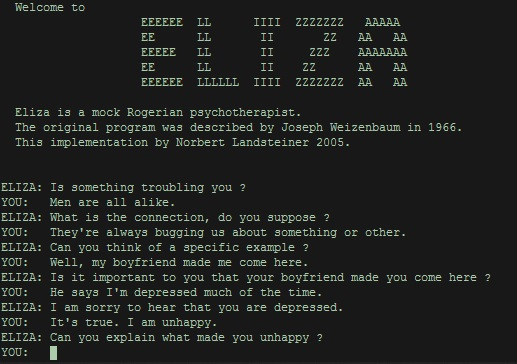<div style="font-size:11px;color:#94a3b8;margin-top:4px">ELIZA (1966) &middot; Gemeinfrei / Public Domain &middot; Wikimedia Commons</div></div>

<div style="text-align:center;margin:14px 0">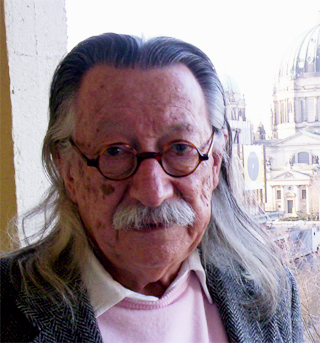<div style="font-size:11px;color:#94a3b8;margin-top:4px">Joseph Weizenbaum &middot; Foto: Ulrich Hansen, CC BY-SA 3.0 &middot; Wikimedia Commons</div></div>

Trotzdem waren Nutzer überzeugt, verstanden zu werden — Weizenbaums eigene Sekretärin bat ihn, den Raum zu verlassen, um „privat" mit ELIZA zu reden.

> 🖥️ **Live ausprobieren:** [ELIZA-Emulator](https://www.masswerk.at/elizabot/) — *versucht, sie zum Stolpern zu bringen. Wie schnell merkt man, dass da niemand „zuhört"?*

---

**② MYCIN (ab 1972) — Regeln können sogar *Experten schlagen*.**

Ein Expertensystem, das bakterielle Infektionen diagnostizierte und Antibiotika empfahl — **so gut wie Fachärzte**. Und trotzdem wurde es **nie klinisch eingesetzt**: Wer haftet, wenn eine Maschine, die man nicht durchschaut, falsch liegt?

> 💡 Merkt euch das: ein System, das *funktioniert*, wird trotzdem nicht genutzt, weil man ihm nicht *vertraut*. Genau darum geht es in der zweiten Semesterhälfte.

---

**③ Deep Blue (1997) — Regeln + Rechenkraft können *übermenschlich* sein.**

Deep Blue schlug den amtierenden Schach-Weltmeister Kasparow — durch massive Suche und handgeschriebene Bewertungsregeln, **ohne zu lernen**.

<div style="text-align:center;margin:14px 0">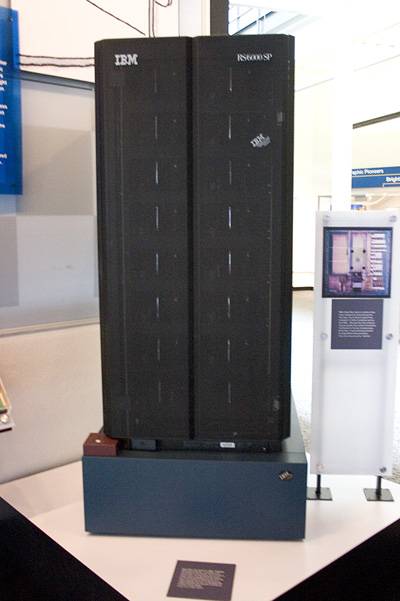<div style="font-size:11px;color:#94a3b8;margin-top:4px">IBM Deep Blue &middot; Foto: Christina Xu, CC BY 2.0 &middot; Wikimedia Commons</div></div>

> ⚠️ **Und doch:** Keines dieser Systeme konnte die *einfache* Sache — eine Katze auf einem Foto erkennen. Regeln waren stark in engen, klaren Domänen und hilflos im Chaos der echten Welt.

---

> 💡 **Kernpunkt:** Regeln skalieren nicht auf die Unordnung der echten Welt. Und schon 1966 vertrauten Menschen einem System, das **nichts** verstand — nur weil es überzeugend klang. Beide Fäden — *Grenzen der Regeln* und *unangebrachtes Vertrauen* — begleiten uns den ganzen Kurs.

---
<sub>¹ Regelbasierte KI: ELIZA (Weizenbaum, MIT, 1966) · Expertensysteme: DENDRAL (Stanford, ab 1965), MYCIN (Stanford, ab 1972), XCON (1980er, kommerziell erfolgreich bei DEC).</sub>


### 2. Der Wechsel: aus Daten lernen

Die ersten Systeme scheiterten an der Unordnung der Welt. Die Lösung war ein Perspektivwechsel — das **maschinelle Lernen**, das Herz der klassischen Big-Data-Ära: statt die Regel *vorzugeben*, zeigt man dem System **viele Beispiele** und lässt es die Regel **selbst finden**.

<div style="text-align:center;margin:16px 0"></div>

> **Nicht:** „So sieht Spam aus" (eine Regel, die Spammer sofort umgehen: „V1AGR4").
> **Sondern:** „Hier sind 10.000 markierte E-Mails — finde selbst heraus, was Spam von Nicht-Spam unterscheidet."

**Das nutzt ihr längst jeden Tag:**

- **Spam-Filter** — lernt aus markierten E-Mails, statt endloser Stichwort-Regeln
- **Empfehlungen** (Netflix, Spotify, Amazon) — gelernt aus Verhalten, nicht aus Regeln
- **Ziffernerkennung** — die Post liest handgeschriebene Postleitzahlen ¹
- **Bilderkennung** — Katze oder Hund? Genau die Frage von eben.

<!-- BILD-PLATZHALTER: MNIST-Ziffern-Raster (Wikimedia Commons, CC/PD, Lizenz prüfen) -->

Die menschliche Arbeit verschiebt sich: weg vom **Regeln-Schreiben**, hin zum **Daten-Sammeln und -Labeln**. Genau hier wurde „big data" wichtig — **mehr (gute) Daten = bessere Modelle.**

> 🐱 **Erinnert ihr euch an die Katze?** In der Regel-Welt konnte niemand aufschreiben, wie man eine Katze auf einem Foto erkennt. Mit maschinellem Lernen geht es — nicht durch eine Regel, sondern durch **tausende markierte Beispiele**. Das war der Durchbruch.

> 💡 **Kernpunkt:** Der Mensch liefert Beispiele und ein Ziel; das **Muster** findet die Maschine. Die Intelligenz steckt nicht mehr in den Regeln — sondern in den Daten.

---
<sub>¹ Handschrift-/Ziffernerkennung: der Klassiker ist der **MNIST**-Datensatz (LeCun u.a., 1990er) — bis heute das „Hallo-Welt" des maschinellen Lernens.</sub>


### 3. Der Deep-Learning-Moment

Neuronale Netze gibt es theoretisch seit Jahrzehnten — schon Hinton, LeCun u.a. legten die Grundlagen. Praktisch **nützlich** wurden sie aber erst, als **drei Dinge zusammenkamen** — alle drei „big-data"-Themen:

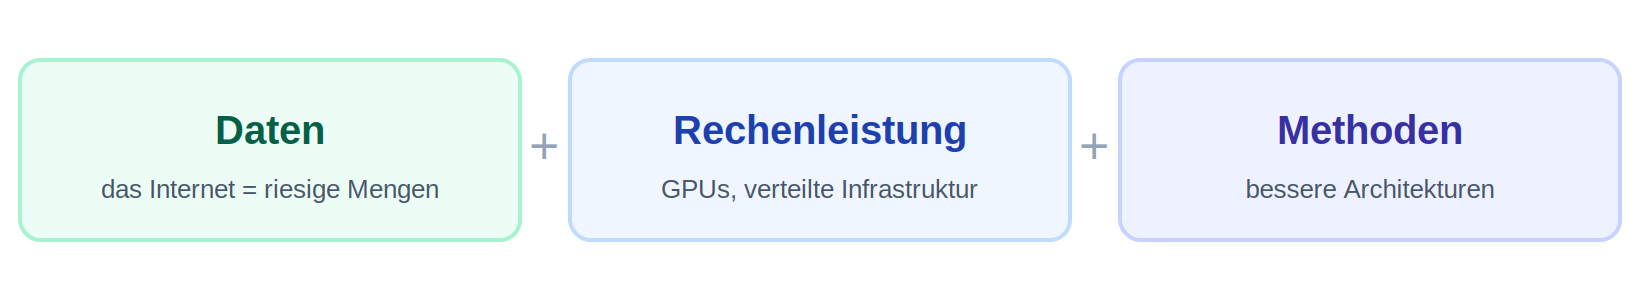

**Der Moment: ImageNet 2012.** Jahrelang lag die Fehlerrate im großen Bilderkennungs-Wettbewerb bei ~26 %, mit mühsam von Hand gebauten Verfahren. 2012 trat ein neuronales Netz namens **AlexNet** an — und halbierte den Fehler auf 15,3 %. Ein Sprung, den niemand für möglich gehalten hatte. Über Nacht war klar: *so* geht es. ¹

Ab da lösten Modelle Aufgaben, die vorher „unmöglich für Computer" waren: Bilderkennung, Spracherkennung, Übersetzung — auf einmal *brauchbar*. Und erinnert ihr euch an die **Katze** aus Teil 1? Genau diese Aufgabe — ein Objekt auf einem Foto erkennen — knackte AlexNet.

> 💡 **Kernpunkt:** Nicht eine geniale Idee allein, sondern **Daten + Rechenleistung + Methode zusammen**. Der Datensatz (ImageNet, aufgebaut von Fei-Fei Li) war dabei so wichtig wie das Modell — ein *Big-Data*-Durchbruch im Wortsinn.

---
<sub>¹ AlexNet (Krizhevsky, Sutskever, Hinton, Univ. Toronto, 2012) gewann den ImageNet-Wettbewerb mit 15,3 % Top-5-Fehler — gegenüber 26,2 % beim Zweitplatzierten. Zutaten: der ImageNet-Datensatz (1,2 Mio. Bilder), GPU-Training, tiefe neuronale Netze.</sub>


### 4. Der LLM-Sprung: warum sich 2022+ anders anfühlte

Große Sprachmodelle (**LLMs**) sind auf riesigen Textmengen trainiert. Möglich wurde das durch eine Architektur namens **Transformer** ¹ — und ein paar Jahre später durch eine Chat-Oberfläche, die plötzlich *jeder* bedienen konnte.

Das Neue war nicht *dass* Maschinen Text verarbeiten, sondern **wie allgemein** sie wurden: **dasselbe** Modell übersetzt, fasst zusammen, klassifiziert, schreibt Code — ohne für jede Aufgabe neu gebaut zu werden.

Zwei Dinge änderten für uns alles:

- **Big Data Analytics wurde auf unstrukturierten Text anwendbar.** Klassisch brauchte man Zahlen in Tabellen. LLMs machen aus Fließtext — Bewertungen, Tickets, Posts — verwertbare Struktur. *(Genau unser Review Radar.)*
- **Man muss kein KI-Spezialist mehr sein.** Aufgabe in normaler Sprache beschreiben (ein *Prompt*) → Ergebnis. Kein Modell-Training, kein Feature-Engineering.

> 💡 **Kernpunkt:** LLMs machten KI zu einem **allgemeinen, per Sprache gesteuerten Werkzeug** — und öffneten Big Data Analytics für freien Text. Damit schließt sich der Kreis: aus „Daten in Tabellen" wurde „Bedeutung in Sprache" — und genau darauf baut dieser Kurs.

---
<sub>¹ Der **Transformer** wurde 2017 von acht Google-Forschern vorgestellt („Attention Is All You Need") — zunächst für maschinelle Übersetzung, dann Grundlage aller großen Sprachmodelle. **ChatGPT** (OpenAI, 30.11.2022) brachte diese Technik in eine Oberfläche, die praktisch jeder nutzen konnte — der Moment, in dem KI „für alle" ankam.</sub>

## Teil B — Wo funktioniert das wirklich?

Der ehrliche Teil. KI ist echt nützlich **und** wird massiv überverkauft — beides gleichzeitig. Eure wertvollste Fähigkeit ist nicht „KI bauen“, sondern **beurteilen, wann sie taugt**.

### 1. Wo es echt funktioniert

KI ist heute in vielen Bereichen real nützlich — kein Hype, sondern Alltag:

- **Sprache in Struktur bringen** — klassifizieren, zusammenfassen, übersetzen. *Beispiel: DeepL, Untertitel, unser Review Radar.*
- **Muster in großen Datenmengen** — Betrugserkennung, Empfehlungen, Prognosen. *Beispiel: „Kunden kauften auch…", Kreditkarten-Warnungen. (Klassische BDA.)*
- **Wahrnehmung** — Bild- und Spracherkennung. *Beispiel: Foto-Suche „zeig mir alle Hunde", Diktier-Funktion.*
- **Assistenz** — Entwürfe, Code, Boilerplate. *Beispiel: erster Entwurf einer E-Mail, Code-Vorschläge.*

**Was diese Fälle gemeinsam haben — die zwei Bedingungen:**

- **Großes Volumen** — mehr Daten, als ein Mensch je durchsehen könnte. *Hier* spielt KI ihre Stärke aus.
- **Fehlertoleranz** — ein *einzelner* Fehler ist nicht katastrophal. Eine schlecht übersetzte Zeile, eine mäßige Empfehlung, ein verworfener Code-Vorschlag — man merkt es, korrigiert, weiter geht's.

> 💡 **Kernpunkt:** KI glänzt, wo **Volumen** auf **Fehlertoleranz** trifft. Fehlt eine der beiden Bedingungen, wird es heikel — genau darum geht es gleich (*wo es scheitert*).

### 2. Das gemeinsame Muster

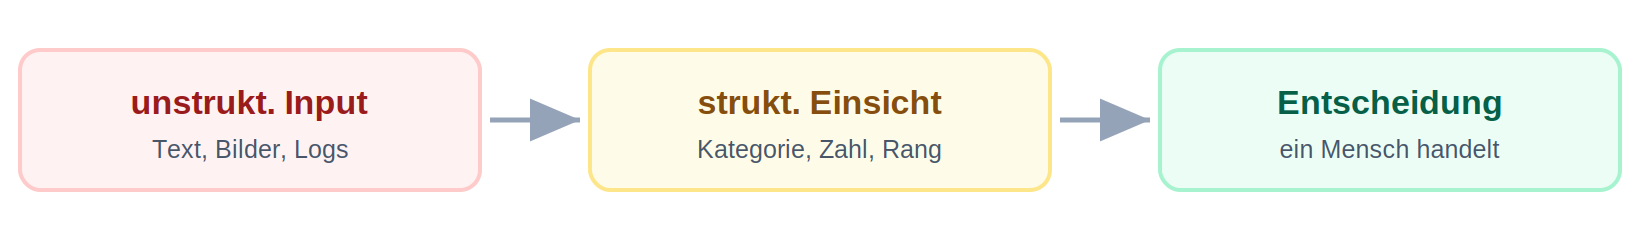

Das ist **genau unser Produkt** (Bewertungen → Sentiment/Themen → „was verbessern wir?“). Übertragbar: Support-Tickets, Umfragen, Social Media — dasselbe Muster, andere Quelle.

> 💡 **Kernpunkt:** Ein Muster, viele Anwendungsfälle. Einmal verstanden, überall anwendbar.

### 3. Wo es scheitert — und das ist wichtiger

- **Selbstbewusst falsch** — plausible, aber falsche Antwort; ohne Prüfung merkt es niemand
- **Verzerrte Daten** — schiefe Daten → das Modell reproduziert und skaliert die Schieflage
- **Kein echtes Verständnis** — erkennt Muster, „versteht“ nichts; bricht bei Ungewohntem ein
- **Der Hype-Aufschlag** — vieles „KI“-Etikettierte ist simpel oder funktioniert nicht

> 💡 **Kernpunkt:** Nicht „kann KI das?“, sondern: **woher weiß ich, ob das Ergebnis stimmt — und was kostet ein Fehler?**

> ⚠️ **FAKT PRÜFEN:** Bei konkretem Fehlschlag-Beispiel einen gut dokumentierten Fall verifizieren, statt aus dem Gedächtnis erzählen.

### 4. Die ehrliche Mitte

KI ist weder Magie noch Schwindel — ein **Werkzeug mit einem Job**: großes Textvolumen bewältigen, das kein Mensch durchliest — solange man weiß, wo es lügt, und einen Menschen an den richtigen Stellen einbaut.

Diese Haltung — nützlich *und* skeptisch — zieht sich durch den Kurs.

### Der tiefere Punkt: „Eine Aufgabe ist eine Entscheidung“

Wenn wir sagen „ordne die Bewertung als **positiv / negativ / neutral** ein“, klingt das objektiv. Ist es nicht — es ist eine **Entscheidung, die wir treffen**:

- Ist „okay, tut was es soll“ positiv oder neutral?
- Lob *und* Kritik zugleich — positiv, negativ, „gemischt“?
- Ist Sarkasmus („super, schon kaputt“) positiv, weil „super“ drinsteht?

Es gibt keine Kategorie „da draußen“, die wir nur ablesen. **Wir erfinden die Kategorien** — und damit auch, was später „richtig“ heißt.

> 💡 **Kernpunkt:** Bevor man misst, ob ein Modell richtig liegt, muss man entscheiden, was „richtig“ überhaupt bedeuten soll. *(Roter Faden der 2. Hälfte.)*

## Ausblick & Setup-Check

**Warum Produktbewertungen?** Messiger echter Text, echter Geschäftswert, und jeder Fehlermodus taucht auf (Sarkasmus, Fakes, gemischte Meinungen).

**Jetzt — Setup-Check:** alle öffnen einmal das Repo in Colab und führen eine Zelle aus. Damit nächste Woche nicht mit 20 kaputten Laptops beginnt.

**Nächste Woche (14.10):** das erste echte Stück Code — ein LLM ordnet die erste Bewertung ein.

> 💡 Das im Kurs gebaute Werkzeug ist eure Prüfungs-Vorlage. Ab jetzt bauen wir es.